In [1]:
import h5py
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.utils.class_weight import compute_class_weight

In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [19]:
from sklearn.metrics import f1_score, log_loss

In [5]:
import matplotlib.pyplot as plt
from matplotlib import image

import os

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from keras.datasets import mnist, cifar10
from keras.utils import to_categorical
from keras.applications.resnet import preprocess_input
from keras.applications import ResNet50
from keras.applications import imagenet_utils
from keras.callbacks import EarlyStopping


In [6]:
import tensorflow as tf
import numpy as np
import random

In [7]:
import librosa
import cv2

In [8]:
# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## Data Preparation

In [9]:
f = h5py.File('bird_spectrograms.hdf5', 'r')
list(f.keys())
#dset = f['species_key_from_list']
#dset.shape

['amecro',
 'amerob',
 'bewwre',
 'bkcchi',
 'daejun',
 'houfin',
 'houspa',
 'norfli',
 'rewbla',
 'sonspa',
 'spotow',
 'whcspa']

In [10]:
list(f.keys())

['amecro',
 'amerob',
 'bewwre',
 'bkcchi',
 'daejun',
 'houfin',
 'houspa',
 'norfli',
 'rewbla',
 'sonspa',
 'spotow',
 'whcspa']

The above list appears to be the bird species names.
Next see what other data is included.

In [11]:
for key in f.keys():
    print(key, f[key].shape)

amecro (128, 517, 66)
amerob (128, 517, 172)
bewwre (128, 517, 144)
bkcchi (128, 517, 45)
daejun (128, 517, 125)
houfin (128, 517, 84)
houspa (128, 517, 630)
norfli (128, 517, 37)
rewbla (128, 517, 187)
sonspa (128, 517, 263)
spotow (128, 517, 137)
whcspa (128, 517, 91)


## Binary Model
Data Preparation
Separate out the bewwre and spotow to use for binary classification.
Choose these two because the have a similar number of examples.

In [12]:
class_names = ['bewwre', 'spotow']

X_list = []
Y_list = []

for label_index, label in enumerate(class_names):
    data = f[label][:]

    data = np.transpose(data, (2, 0, 1))

    X_list.append(data)
    Y_list.append(np.full(data.shape[0], label_index))

X_binary = np.concatenate(X_list, axis = 0)
Y_binary = np.concatenate(Y_list, axis = 0)

print(X_binary.shape, Y_binary.shape)

(281, 128, 517) (281,)


In [13]:
print("Min:", X_binary.min())
print("Max:", X_binary.max())

Min: -80.0
Max: 1.9073486328125e-06


In [14]:
X_binary = X_binary[..., np.newaxis]

# Scale to the [-1, 0] range because my min is -80
X_binary = X_binary.astype('float32')
X_binary = X_binary / 80
print("Min:", X_binary.min())
print("Max:", X_binary.max())

Min: -1.0
Max: 2.3841858e-08


Split into train and test sets.

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_binary, Y_binary,
    test_size=0.2,
    stratify=Y_binary,
    random_state=42
)

Specify the CNN. Use a small model since I have 281 examples.

In [16]:
model_cnn = Sequential(
    [
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

model_cnn.summary()

C:\Users\Veteran\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 517, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 258, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 258, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 129, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 129, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,217,729 (16.09 MB)

 Trainable params: 4,217,729 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

Fit the model.

In [17]:
%%time

model_cnn.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=16,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4804 - loss: 0.9598 - val_accuracy: 0.6667 - val_loss: 0.6872
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5084 - loss: 0.6930 - val_accuracy: 0.3333 - val_loss: 0.7515
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5587 - loss: 0.7009 - val_accuracy: 0.3333 - val_loss: 0.7002
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5587 - loss: 0.6900 - val_accuracy: 0.3333 - val_loss: 0.7479
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5587 - loss: 0.6964 - val_accuracy: 0.3333 - val_loss: 0.7045
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5587 - loss: 0.6892 - val_accuracy: 0.3333 - val_loss: 0.7151
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5587 - loss: 0.6882 - val_accuracy: 0.3333 - val_loss: 0.7419
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5587 - loss: 0.6872 - val_accuracy: 0.3333 - v

The model is still improving, so try more epochs with early stopping.

Create a confusion matrix.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


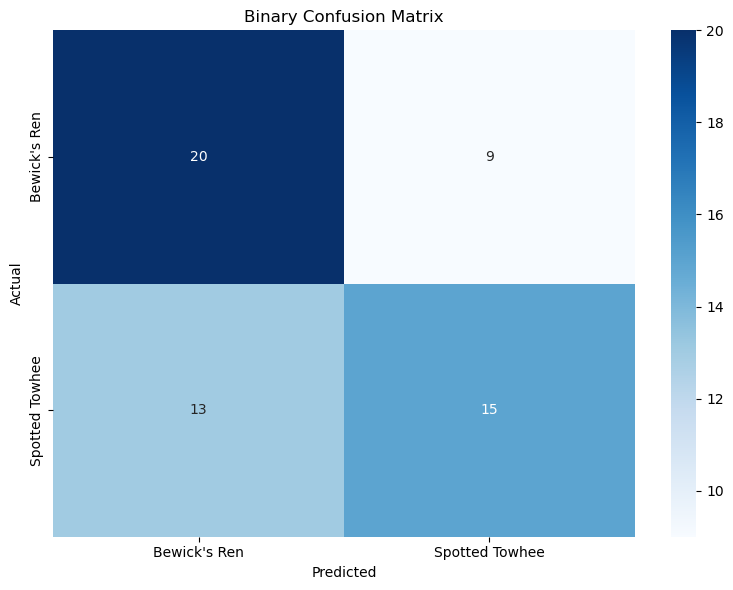

In [18]:
Y_pred = model_cnn.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype(int).flatten()

# True labels
#Y_true = Y_test

cm = confusion_matrix(y_true=Y_test, y_pred=Y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Bewick's Ren", 'Spotted Towhee'],
            yticklabels=["Bewick's Ren", 'Spotted Towhee'],
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Binary Confusion Matrix')
plt.tight_layout()
plt.show()

Compute F1 and Log Loss.

In [20]:
print("F1:", f1_score(Y_test, Y_pred_classes))
print("Log Loss:", log_loss(Y_test, Y_pred))

F1: 0.5769230769230769
Log Loss: 0.6741182709843211


In [ ]:
Plot training vs validation accuracy

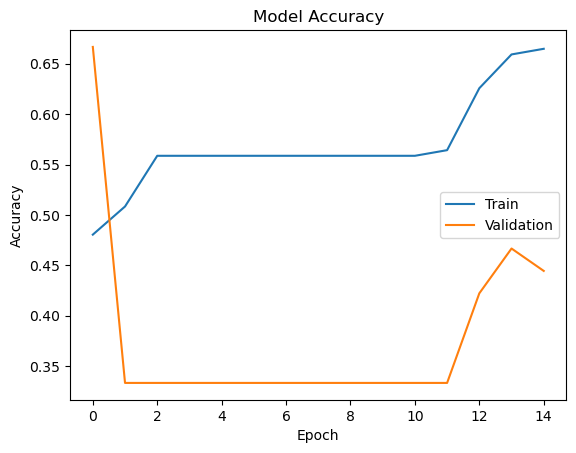

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
Plot training vs validation loss

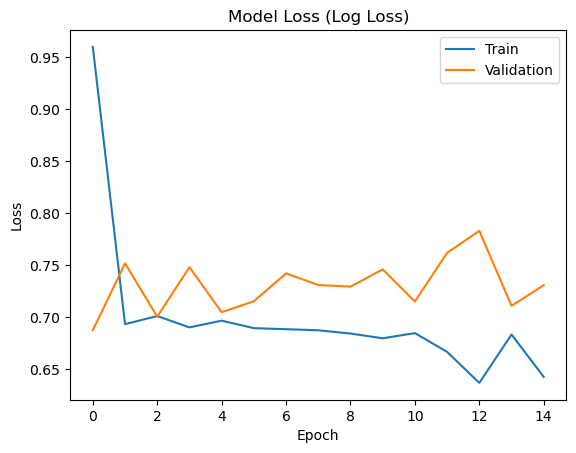

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [14]:
model_cnn = Sequential(
    [
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

In [17]:
%%time

model_cnn.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor  = 'val_loss',
    patience = 3,
    restore_best_weights = True)

history = model_cnn.fit(X_train, Y_train,
                        epochs=30,
                        batch_size=16,
                        validation_split=0.2,
                        callbacks = [early_stop],
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5642 - loss: 0.7044 - val_accuracy: 0.6667 - val_loss: 0.6772
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5251 - loss: 0.6908 - val_accuracy: 0.3333 - val_loss: 0.9372
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5084 - loss: 0.7353 - val_accuracy: 0.6667 - val_loss: 0.6863
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5531 - loss: 0.6916 - val_accuracy: 0.3333 - val_loss: 0.7294
Test Accuracy: 49.12%
CPU times: total: 26.2 s
Wall time: 3.59 s


Try a higher patience because early stopping stopped too soon, possibly because my data is small and the validation metrics are noisy.

In [18]:
model_cnn = Sequential(
    [
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

In [19]:
%%time

model_cnn.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor  = 'val_loss',
    patience = 6,
    restore_best_weights = True)

history = model_cnn.fit(X_train, Y_train,
                        epochs=30,
                        batch_size=16,
                        validation_split=0.2,
                        callbacks = [early_stop],
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5810 - loss: 1.1012 - val_accuracy: 0.3333 - val_loss: 0.7563
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5587 - loss: 0.6917 - val_accuracy: 0.3333 - val_loss: 0.7253
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5587 - loss: 0.7010 - val_accuracy: 0.3333 - val_loss: 0.7156
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5698 - loss: 0.6889 - val_accuracy: 0.4000 - val_loss: 0.6974
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6089 - loss: 0.6880 - val_accuracy: 0.4222 - val_loss: 0.7189
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5866 - loss: 0.6743 - val_accuracy: 0.5333 - val_loss: 0.7108
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6760 - loss: 0.6454 - val_accuracy: 0.5556 - val_loss: 0.7079
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7430 - loss: 0.5713 - val_accuracy: 0.4889 - v

This model performed best without early stopping. Now try a larger model.

In [20]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

In [21]:
%%time

model_cnn.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=16,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.5419 - loss: 0.9787 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.5642 - loss: 0.6927 - val_accuracy: 0.3333 - val_loss: 0.6986
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.5642 - loss: 0.7052 - val_accuracy: 0.3333 - val_loss: 0.7020
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.5587 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.7615
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.5587 - loss: 0.6926 - val_accuracy: 0.3333 - val_loss: 0.7144
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.5587 - loss: 0.6865 - val_accuracy: 0.3333 - val_loss: 0.7517
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.4916 - loss: 0.6948 - val_accuracy: 0.3556 - val_loss: 0.6946
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.5698 - loss: 0.6767 - val_accuracy: 0.

The smaller model performed better. The larger model overfit the small data set, which resulted in lower test accuracy. 
Try a different dropout rate on the smaller model.

In [22]:
model_cnn = Sequential(
    [
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.3),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

In [23]:
%%time

model_cnn.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=16,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5419 - loss: 0.9566 - val_accuracy: 0.3333 - val_loss: 0.7311
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5587 - loss: 0.6905 - val_accuracy: 0.3333 - val_loss: 0.7149
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5587 - loss: 0.6927 - val_accuracy: 0.3333 - val_loss: 0.7183
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5587 - loss: 0.6935 - val_accuracy: 0.3778 - val_loss: 0.6934
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5475 - loss: 0.6937 - val_accuracy: 0.3333 - val_loss: 0.7271
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5028 - loss: 0.6932 - val_accuracy: 0.3333 - val_loss: 0.6992
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5587 - loss: 0.6880 - val_accuracy: 0.3333 - val_loss: 0.7358
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5587 - loss: 0.6854 - val_accuracy: 0.3333 - v

The original model was the best. The smaller dropout rate did not improve the model, likely due to the small data set.

## Multi-class Model

Data Preparation
Create X and Y to later split into train and test sets.

In [23]:
X_list = []
Y_list = []
labels = list(f.keys())
for label_index, label in enumerate(labels):
    data = f[label][:]

    data = np.transpose(data, (2, 0, 1))

    X_list.append(data)
    Y_list.append(np.full(data.shape[0], label_index))

X = np.concatenate(X_list, axis = 0)
Y = np.concatenate(Y_list, axis = 0)

print(X.shape, Y.shape)

(1981, 128, 517) (1981,)


In [24]:
print("Min:", X.min())
print("Max:", X.max())

Min: -80.0
Max: 3.814697265625e-06


In [25]:
X = X[..., np.newaxis]

# Scale to the [-1, 0] range because my min is -80
X = X.astype('float32')
X = X / 80
print("Min:", X.min())
print("Max:", X.max())

Min: -1.0
Max: 4.7683717e-08


In [26]:
# one-hot encode labels
Y = to_categorical(Y, num_classes=12)
Y.shape

(1981, 12)

In [27]:
# split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y.argmax(axis=1),
    random_state=42
)

Specify the CNN. Start with a larger model since I have more data.

In [29]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

model_cnn.summary()

C:\Users\Veteran\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 129, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,871,564 (64.36 MB)

 Trainable params: 16,871,564 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

Fit the model.

In [30]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 309ms/step - accuracy: 0.2802 - loss: 2.4759 - val_accuracy: 0.3438 - val_loss: 2.1199
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.3118 - loss: 2.1869 - val_accuracy: 0.3438 - val_loss: 2.1361
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 294ms/step - accuracy: 0.3125 - loss: 2.1475 - val_accuracy: 0.3502 - val_loss: 2.0844
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 299ms/step - accuracy: 0.3489 - loss: 2.0147 - val_accuracy: 0.4196 - val_loss: 1.9450
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.4175 - loss: 1.8416 - val_accuracy: 0.4006 - val_loss: 1.9281
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.4696 - loss: 1.6655 - val_accuracy: 0.4700 - val_loss: 1.7681
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.5288 - loss: 1.4447 - val_accuracy: 0.4606 - val_loss: 1.7492
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - accuracy: 0.6069 - loss: 1.2250 - val_accu

The model seems to be overfitting, likely because multiclass classification is harder. Also, the binary data set was relatively balanced, but this one is  not. Try a smaller model with a higher dropout and fewer epochs.

In [77]:
# Plot confusion matrix
Y_pred = model_cnn.predict(X_test)
Y_pred_classes = Y_pred.argmax(axis = 1)
cm = confusion_matrix(y_true = Y_test.argmax(axis = 1), y_pred = Y_pred_classes)
plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
sns.set_theme(font_scale = 1.2)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


AxisError: axis 1 is out of bounds for array of dimension 1

In [31]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.6),
    Dense(units=64, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

In [32]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=10,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 0.2802 - loss: 2.2897 - val_accuracy: 0.3438 - val_loss: 2.1277
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - accuracy: 0.3118 - loss: 2.1968 - val_accuracy: 0.3438 - val_loss: 2.1316
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.3118 - loss: 2.1954 - val_accuracy: 0.3438 - val_loss: 2.1025
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - accuracy: 0.3118 - loss: 2.1920 - val_accuracy: 0.3438 - val_loss: 2.1662
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - accuracy: 0.3118 - loss: 2.1846 - val_accuracy: 0.3438 - val_loss: 2.1175
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.3125 - loss: 2.1047 - val_accuracy: 0.3502 - val_loss: 2.0292
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.3323 - loss: 2.0297 - val_accuracy: 0.3754 - val_loss: 1.9759
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.3852 - loss: 1.9099 - val_accuracy: 

Now the model is underfitting. Try keeping the model small and returning dropout and dense to the values of the first model.

In [33]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

In [34]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=10,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.2652 - loss: 2.3943 - val_accuracy: 0.3438 - val_loss: 2.1142
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.3118 - loss: 2.1935 - val_accuracy: 0.3438 - val_loss: 2.1112
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.3118 - loss: 2.1740 - val_accuracy: 0.3375 - val_loss: 2.1956
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.3118 - loss: 2.2035 - val_accuracy: 0.3407 - val_loss: 2.1028
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.3102 - loss: 2.1659 - val_accuracy: 0.3407 - val_loss: 2.0896
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.3252 - loss: 2.1099 - val_accuracy: 0.3470 - val_loss: 2.0309
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.3512 - loss: 1.9875 - val_accuracy: 0.4227 - val_loss: 1.8984
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.4144 - loss: 1.8276 - val_accura

This model is also underfitting. We should deal with the class imbalance.
Compute class weights and use them in training.

In [36]:
y_train_labels = Y_train.argmax(axis=1)

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.490566037735849), 1: np.float64(0.9635036496350365), 2: np.float64(1.1478260869565218), 3: np.float64(3.6666666666666665), 4: np.float64(1.32), 5: np.float64(1.9701492537313432), 6: np.float64(0.2619047619047619), 7: np.float64(4.4), 8: np.float64(0.8859060402684564), 9: np.float64(0.6285714285714286), 10: np.float64(1.2), 11: np.float64(1.8082191780821917)}


In [37]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

C:\Users\Veteran\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=32,
                        validation_split=0.2,
                        class_weight = class_weights,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - accuracy: 0.0568 - loss: 2.6174 - val_accuracy: 0.0599 - val_loss: 2.4865
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 0.0837 - loss: 2.5064 - val_accuracy: 0.0726 - val_loss: 2.4871
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.0750 - loss: 2.5062 - val_accuracy: 0.0726 - val_loss: 2.4895
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.0766 - loss: 2.5059 - val_accuracy: 0.0473 - val_loss: 2.4908
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.0789 - loss: 2.5044 - val_accuracy: 0.0473 - val_loss: 2.4985
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.0797 - loss: 2.5041 - val_accuracy: 0.0473 - val_loss: 2.4919
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.0797 - loss: 2.5020 - val_accuracy: 0.0473 - val_loss: 2.5115
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.0797 - loss: 2.5009 - val_accura

Raw class weights caused what seems to be random guessing. Try changing the weighting.

In [40]:
for k in class_weights:
    class_weights[k] = 1 + 0.5 * (class_weights[k] - 1)

print(class_weights)

{0: np.float64(1.7452830188679245), 1: np.float64(0.9817518248175183), 2: np.float64(1.0739130434782609), 3: 2.0, 4: np.float64(1.1600000000000001), 5: np.float64(1.4850746268656716), 6: np.float64(0.6309523809523809), 7: 2.0, 8: np.float64(0.9429530201342282), 9: np.float64(0.8142857142857143), 10: np.float64(1.1), 11: np.float64(1.404109589041096)}


In [41]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

In [42]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=32,
                        validation_split=0.2,
                        class_weight = class_weights,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.2920 - loss: 2.4104 - val_accuracy: 0.3438 - val_loss: 2.3390
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 237ms/step - accuracy: 0.3118 - loss: 2.3670 - val_accuracy: 0.3438 - val_loss: 2.2273
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.3118 - loss: 2.3643 - val_accuracy: 0.3407 - val_loss: 2.2353
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.3039 - loss: 2.3635 - val_accuracy: 0.3438 - val_loss: 2.2396
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.3102 - loss: 2.3362 - val_accuracy: 0.3281 - val_loss: 2.1877
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step - accuracy: 0.3102 - loss: 2.2980 - val_accuracy: 0.3596 - val_loss: 2.1504
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.3599 - loss: 2.1723 - val_accuracy: 0.3975 - val_loss: 1.9181
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.4451 - loss: 1.8761 - val_accurac

The unweighted model performed slightly better than the weighted model.
Need to rerun the best model so that it will be the one used when testing the external data.
Try using more epochs to see if the  model will improve since it was underfitting.

In [48]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

In [49]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=15,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.2976 - loss: 2.3394 - val_accuracy: 0.3438 - val_loss: 2.1225
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.3118 - loss: 2.2003 - val_accuracy: 0.3438 - val_loss: 2.1187
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 0.3125 - loss: 2.1926 - val_accuracy: 0.3438 - val_loss: 2.0865
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.3110 - loss: 2.1851 - val_accuracy: 0.3438 - val_loss: 2.0783
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.3307 - loss: 2.0646 - val_accuracy: 0.4227 - val_loss: 1.9803
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.4199 - loss: 1.8768 - val_accuracy: 0.4164 - val_loss: 1.9190
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step - accuracy: 0.4704 - loss: 1.6780 - val_accuracy: 0.4921 - val_loss: 1.7423
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.5272 - loss: 1.5000 - val_accura

Run it again with 10 epochs since it had better results.

In [28]:
model_cnn = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

C:\Users\Veteran\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
%%time

model_cnn.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

history = model_cnn.fit(X_train, Y_train,
                        epochs=10,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=1)

score = model_cnn.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.2904 - loss: 2.2793 - val_accuracy: 0.3438 - val_loss: 2.1166
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - accuracy: 0.3118 - loss: 2.2012 - val_accuracy: 0.3438 - val_loss: 2.1056
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.3118 - loss: 2.1877 - val_accuracy: 0.3438 - val_loss: 2.0981
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.3125 - loss: 2.1630 - val_accuracy: 0.3344 - val_loss: 2.0832
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.3449 - loss: 2.0332 - val_accuracy: 0.3975 - val_loss: 1.9926
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.4317 - loss: 1.8337 - val_accuracy: 0.4353 - val_loss: 1.8659
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.4743 - loss: 1.6474 - val_accuracy: 0.4416 - val_loss: 1.8477
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.5304 - loss: 1.4449 - val_accuracy

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


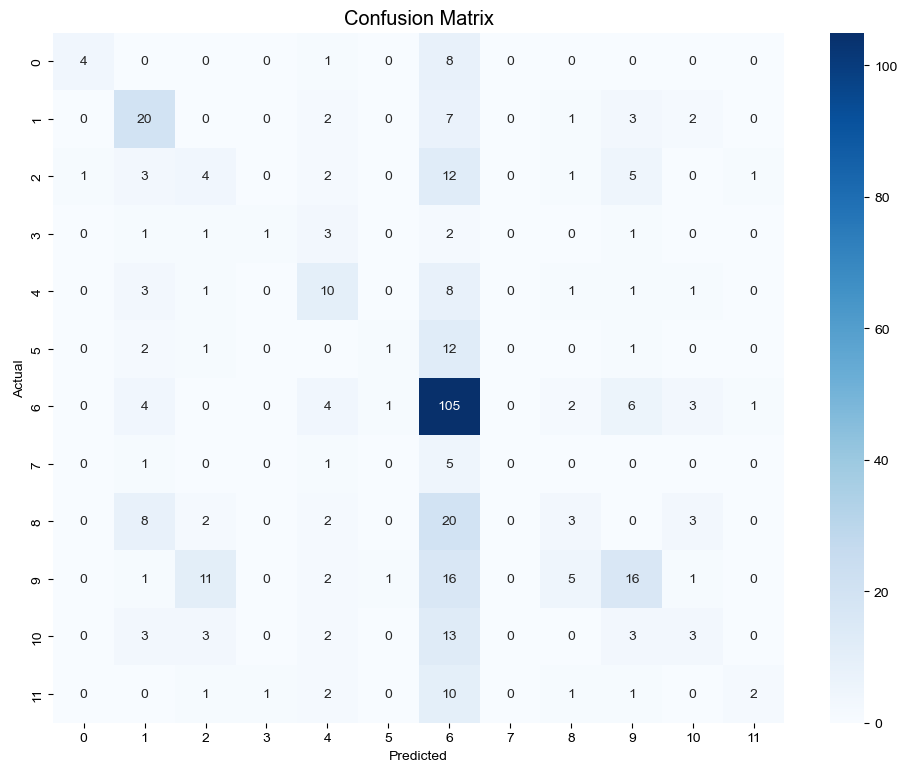

In [30]:
# Plot confusion matrix
Y_pred = model_cnn.predict(X_test)
Y_pred_classes = Y_pred.argmax(axis = 1)
cm = confusion_matrix(y_true = Y_test.argmax(axis = 1), y_pred = Y_pred_classes)
plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
sns.set_theme(font_scale = 1.2)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [32]:
# Get predicted probabilities
Y_pred = model_cnn.predict(X_test)

# Convert BOTH to class labels
Y_true_classes = np.argmax(Y_test, axis=1)
Y_pred_classes = np.argmax(Y_pred, axis=1)

# Compute metrics
print("Macro F1:", f1_score(Y_true_classes, Y_pred_classes, average='macro'))
print("Log Loss:", log_loss(Y_test, Y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Macro F1: 0.2617832924302623
Log Loss: 2.0527532956995356


In [ ]:
Plot training versus validation accuracy 

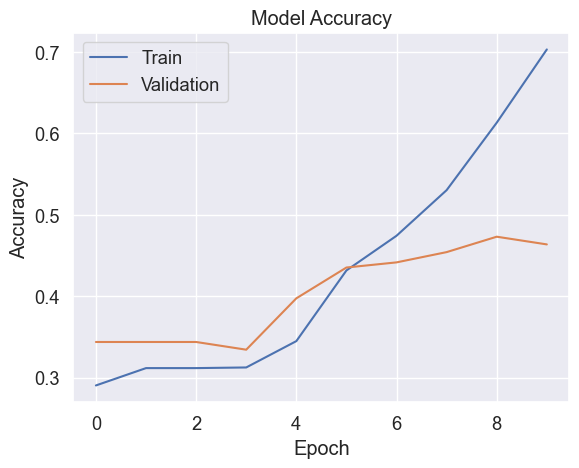

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
Plot training versus validation loss

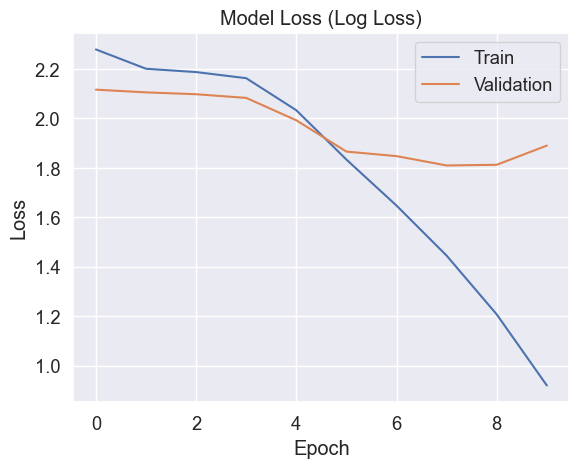

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## External Test Data

In [35]:
from IPython.display import Audio

Audio("test1.mp3")

In [36]:
Audio("test2.mp3")

In [37]:
Audio("test3.mp3")

Split into 2 second chunks.

In [38]:
def split_and_extract(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    
    window_size = 2 * sr   # ✅ 2 seconds
    
    specs = []
    
    for i in range(0, len(y) - window_size, window_size):
        chunk = y[i:i+window_size]
        
        S = librosa.feature.melspectrogram(
            y=chunk,
            sr=sr,
            n_mels=128
        )
        
        S_db = librosa.power_to_db(S, ref=np.max)
        
        specs.append(S_db)
    
    return specs

Functions to predict each chunk.

In [39]:
def prepare_input(spec):
    # resize spectrogram to match training shape
    spec_resized = cv2.resize(spec, (517, 128))   # (width, height)
    
    # normalize (same as training)
    spec_resized = spec_resized / 80.0
    
    # add batch + channel dimensions
    spec_resized = spec_resized[np.newaxis, ..., np.newaxis]
    
    return spec_resized

In [40]:
def predict_clip(file_path):
    specs = split_and_extract(file_path)
    
    predictions = []
    
    for spec in specs:
        X = prepare_input(spec)  # your resize + normalize
        
        pred = model_cnn.predict(X)
        pred_class = np.argmax(pred)
        
        predictions.append(labels[pred_class])
    
    return predictions

Predict what birds are heard in each test file.

In [41]:
predictions_test1 = predict_clip("test1.mp3")
print(predictions_test1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
['houspa', 'houspa', 'houspa', 'houspa', 'rewbla', 'houspa', 'houspa', 'houspa', 'houspa', 'houspa', 'houspa']


In [42]:
predictions_test2 = predict_clip("test2.mp3")
print(predictions_test2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
['houspa', 'houspa']


In [43]:
predictions_test3 = predict_clip("test3.mp3")
print(predictions_test3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
['houspa', 'houspa', 'houspa', 'houspa', 'bkcchi', 'houspa', 'houspa']


In [44]:
def predict_clip_with_probs(file_path):
    specs = split_and_extract(file_path)
    
    all_preds = []
    
    for spec in specs:
        X = prepare_input(spec)
        pred = model_cnn.predict(X)  # shape: (1, num_classes)
        
        all_preds.append(pred[0])   # store full probability vector
    
    return np.array(all_preds)

In [45]:
probs_test1 = predict_clip_with_probs("test1.mp3")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


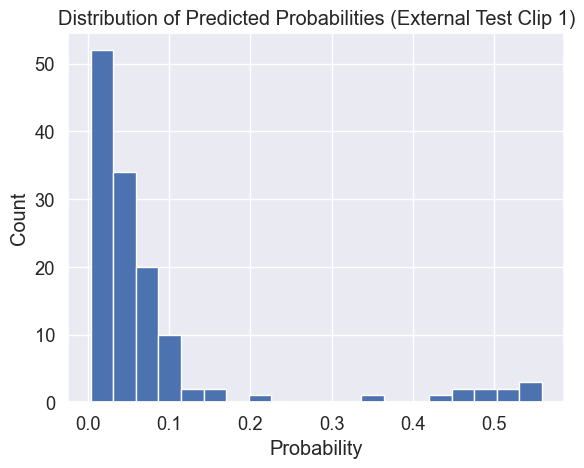

In [49]:
plt.hist(probs_test1.flatten(), bins=20)
plt.title("Distribution of Predicted Probabilities (External Test Clip 1)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

In [47]:
for i, p in enumerate(probs_test1[:5]):
    print(f"Chunk {i}: {p}")

Chunk 0: [0.01763168 0.08642383 0.03523746 0.03188559 0.01731143 0.02152807
 0.51276964 0.06608821 0.10786863 0.04429366 0.03873601 0.02022569]
Chunk 1: [0.0297124  0.06735313 0.02419378 0.04788883 0.02287839 0.02672545
 0.48296124 0.08119376 0.10276806 0.0428485  0.02926502 0.04221139]
Chunk 2: [0.03814917 0.09003981 0.0220219  0.10555083 0.02740222 0.03264729
 0.35385403 0.05898204 0.11683522 0.08597277 0.02555034 0.04299436]
Chunk 3: [0.01521416 0.09807585 0.02083843 0.04716318 0.00971622 0.04533971
 0.4462942  0.07560167 0.1427767  0.04277914 0.02320068 0.03300002]
Chunk 4: [0.01180771 0.03538681 0.02172071 0.06217247 0.01000769 0.00499793
 0.20857611 0.0466316  0.4765413  0.08031448 0.01307273 0.02877052]


In [48]:
for i, p in enumerate(probs_test1[:5]):
    pred_class = np.argmax(p)
    confidence = np.max(p)
    print(f"Chunk {i}: {labels[pred_class]} ({confidence:.2f})")

Chunk 0: houspa (0.51)
Chunk 1: houspa (0.48)
Chunk 2: houspa (0.35)
Chunk 3: houspa (0.45)
Chunk 4: rewbla (0.48)


In [51]:
probs_test2 = predict_clip_with_probs("test2.mp3")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


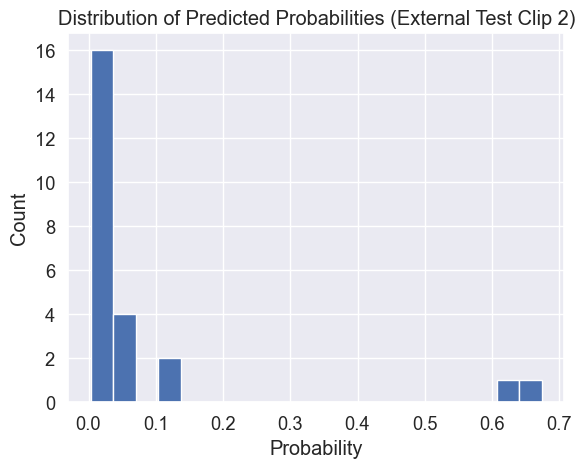

In [54]:
plt.hist(probs_test2.flatten(), bins=20)
plt.title("Distribution of Predicted Probabilities (External Test Clip 2)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

In [53]:
for i, p in enumerate(probs_test2[:5]):
    pred_class = np.argmax(p)
    confidence = np.max(p)
    print(f"Chunk {i}: {labels[pred_class]} ({confidence:.2f})")

Chunk 0: houspa (0.67)
Chunk 1: houspa (0.63)


In [55]:
probs_test3 = predict_clip_with_probs("test3.mp3")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


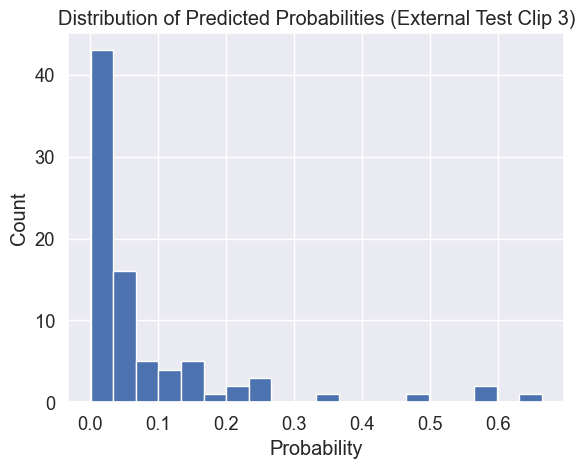

In [56]:
plt.hist(probs_test3.flatten(), bins=20)
plt.title("Distribution of Predicted Probabilities (External Test Clip 3)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

In [58]:
for i, p in enumerate(probs_test3[:5]):
    pred_class = np.argmax(p)
    confidence = np.max(p)
    print(f"Chunk {i}: {labels[pred_class]} ({confidence:.2f})")

Chunk 0: houspa (0.24)
Chunk 1: houspa (0.57)
Chunk 2: houspa (0.26)
Chunk 3: houspa (0.57)
Chunk 4: bkcchi (0.36)


## View Spectrograms

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Number of confused samples (9 → 2): 11


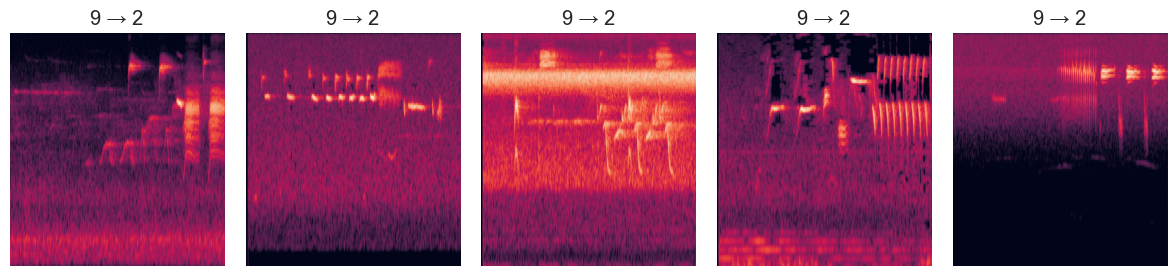

In [59]:
Y_test_labels = Y_test.argmax(axis=1)

# Get predictions
Y_pred = model_cnn.predict(X_test)
Y_pred_classes = Y_pred.argmax(axis=1)

# Find misclassified samples: actual 9, predicted 2
confused_idx = np.where(
    (Y_test_labels == 9) & (Y_pred_classes == 2)
)[0]

print("Number of confused samples (9 → 2):", len(confused_idx))

# Plot spectrograms
plt.figure(figsize=(12, 3))

for i, idx in enumerate(confused_idx[:5]):  # show up to 5
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx].squeeze(), aspect='auto', origin='lower')
    plt.title("9 → 2")
    plt.axis('off')

plt.tight_layout()
plt.show()

Number of class 2 samples: 29


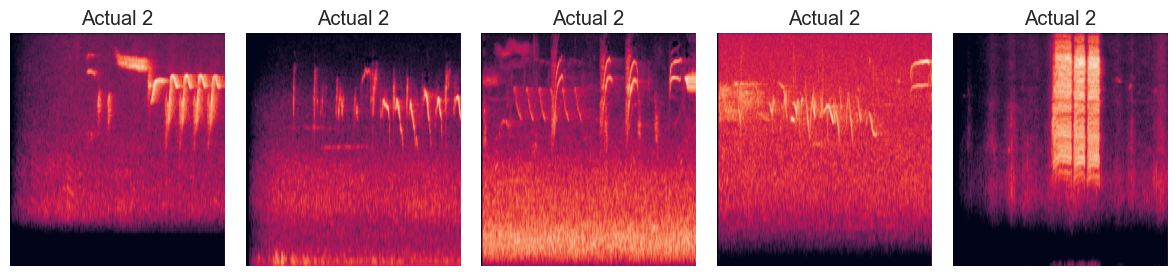

In [60]:
# Get indices where the true class is 2
idx_class2 = np.where(Y_test_labels == 2)[0]

print("Number of class 2 samples:", len(idx_class2))

# Plot some examples
plt.figure(figsize=(12, 3))

for i, idx in enumerate(idx_class2[:5]):  # show 5 examples
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx].squeeze(), aspect='auto', origin='lower')
    plt.title("Actual 2")
    plt.axis('off')

plt.tight_layout()
plt.show()